In [6]:
import matplotlib.pyplot as plt
import numpy as np
from fastdtw import fastdtw
from scipy.spatial.distance import cosine, correlation
from scipy.stats import wilcoxon
from tqdm.notebook import tqdm

from analysis_helpers import Episode, Participant

In [7]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

In [8]:
episode_traj = atlep1.trajectory

dtw_to_episode = []
dtw_to_immediate = []
subids = []

for p in tqdm(participants, desc='Computing DTW distances'):
    delayed_traj = p.trajectories['delayed']
    immediate_traj = p.trajectories['atlep1']

    dist_episode, _ = fastdtw(delayed_traj, episode_traj, dist=correlation)#cosine)
    dist_immediate, _ = fastdtw(delayed_traj, immediate_traj, dist=correlation)#cosine)

    dtw_to_episode.append(dist_episode)
    dtw_to_immediate.append(dist_immediate)
    subids.append(p.subid)

dtw_to_episode = np.array(dtw_to_episode)
dtw_to_immediate = np.array(dtw_to_immediate)

Computing DTW distances:   0%|          | 0/57 [00:00<?, ?it/s]

In [ ]:
stat, pvalue = wilcoxon(dtw_to_immediate, dtw_to_episode, alternative='less')
n = len(dtw_to_episode)

print(f'n = {n} participants')
print(f'Median DTW distance (delayed → episode):   {np.median(dtw_to_episode):.3f}')
print(f'Median DTW distance (delayed → immediate): {np.median(dtw_to_immediate):.3f}')
print(f'Wilcoxon signed-rank test (immediate < episode): W = {stat:.1f}, p = {pvalue:.4g}')

n = 57 participants
Median DTW distance (delayed → episode):   720.256
Median DTW distance (delayed → immediate): 666.484
Wilcoxon signed-rank test (immediate < episode): W = 450.0, p = 0.001389


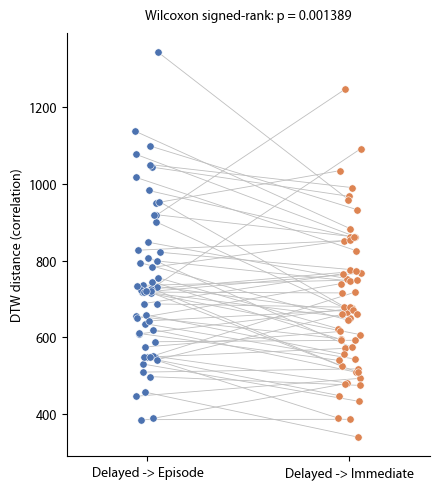

In [ ]:
fig, ax = plt.subplots(figsize=(4.5, 5))

jitter = 0.06
x_episode = np.full(n, 0) + np.random.default_rng(0).uniform(-jitter, jitter, n)
x_immediate = np.full(n, 1) + np.random.default_rng(1).uniform(-jitter, jitter, n)

for i in range(n):
    ax.plot(
        [x_episode[i], x_immediate[i]],
        [dtw_to_episode[i], dtw_to_immediate[i]],
        color='0.75', linewidth=0.6, zorder=1
    )

ax.scatter(x_episode, dtw_to_episode, s=28, color='#4C72B0', edgecolor='white',
           linewidth=0.4, zorder=2, label='Delayed -> Episode')
ax.scatter(x_immediate, dtw_to_immediate, s=28, color='#DD8452', edgecolor='white',
           linewidth=0.4, zorder=2, label='Delayed -> Immediate')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Delayed -> Episode', 'Delayed -> Immediate'])
ax.set_ylabel('DTW distance (correlation)')
ax.set_xlim(-0.4, 1.4)
ax.spines[['top', 'right']].set_visible(False)

p_label = f'p = {pvalue:.4g}' if pvalue >= 0.0001 else f'p < 0.0001'
ax.set_title(f'Wilcoxon signed-rank: {p_label}', fontsize=10, pad=10)

plt.tight_layout()
plt.show()

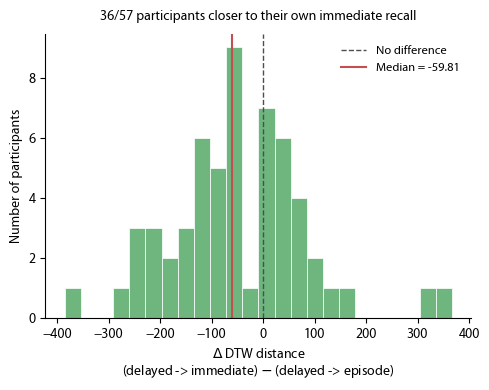

In [ ]:
diff = dtw_to_immediate - dtw_to_episode

fig, ax = plt.subplots(figsize=(5, 4))

bins = np.linspace(np.floor(diff.min()), np.ceil(diff.max()), 25)
ax.hist(diff, bins=bins, color='#55A868', edgecolor='white', linewidth=0.6, alpha=0.85)
ax.axvline(0, color='0.3', linestyle='--', linewidth=1, label='No difference')
ax.axvline(np.median(diff), color='#C44E52', linestyle='-', linewidth=1.5,
           label=f'Median = {np.median(diff):.2f}')

ax.set_xlabel('$\\Delta$ DTW distance\n(delayed -> immediate) $-$ (delayed -> episode)')
ax.set_ylabel('Number of participants')
ax.legend(frameon=False, fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

n_closer_to_immediate = (diff < 0).sum()
ax.set_title(
    f'{n_closer_to_immediate}/{n} participants closer to their own immediate recall',
    fontsize=10, pad=10
)

fig.tight_layout()
plt.show()